
# 7.10 Optimize simulated rhythmic responses

This example demonstrates how to optimize the power spectral density (PSD)
of a current dipole signal with significant alpha and beta spectral
components.


Authors: Carolina Fernandez ( cxf418@miami.edu )

## 1. Import Optimization dependencies

**Please note that in order to run this tutorial you MUST have installed the optimization dependencies for HNN-Core. Normally, these are optional for general HNN-Core use, but they are required for this tutorial. In the next cell, we will check to make sure they are installed, and if they are not, then please follow the directions provided.**


In [2]:
try:
    from hnn_core.optimization import Optimizer
except ImportError:
    raise ImportError("""
The optimization module is not available. Please install the hnn-core package using

    pip install "hnn-core[opt]"

""")

--No graphics will be displayed.


If you installed `hnn_core` using the Python or Conda package (i.e. not from source), then you can **uncomment and run** the following code cell to easily install the optimization dependences into your current Python environment. If you do so, please restart your Jupyter kernel before running the notebook again.

In [3]:
# %pip install -q "hnn-core[opt]"

## 2. Import remaining libraries

Next, let's import the other `hnn_core` modules and external libraries required for this tutorial. Note: it is strongly recommended that you [follow the "MPI Installation" sections of our Installation Guide](https://jonescompneurolab.github.io/textbook/content/01_getting_started/installation.html) if you want to run this tutorial or use Optimization in HNN-Core, since doing so will GREATLY speed up how fast the optimization runs. Optimization is a very compute-heavy operation, and in typical scientific use, MPI can speed up an optimization that would take days into taking only hours to run. If you need help with installation (including MPI), then please reach out on our [Discussion Board](https://github.com/jonescompneurolab/hnn-core/discussions).

In [4]:
import matplotlib.pyplot as plt

from hnn_core import jones_2009_model, simulate_dipole
from hnn_core.viz import plot_psd

# --- Parallel backend ---
# HNN-Core's "MPIBackend" gives the largest speed-up, but requires both the `mpi4py`
# Python package and an MPI installation. If either is missing, we fall back to Joblib,
# which parallelizes *across* trials only, and therefore does not speed up any
# single-trial simulations.
#
# We offer complete guides to installing MPI with HNN-Core at
# https://jonescompneurolab.github.io/textbook/content/01_getting_started/installation.html
# and if you have any installation issues, feel free to reach out to us on our
# Discussion Board at https://github.com/jonescompneurolab/hnn-core/discussions where we
# can help you troubleshoot.
try:
    import mpi4py  # noqa: F401
    import psutil
    n_procs = psutil.cpu_count(logical=False)
    use_mpi = True
    print('Using MPIBackend with %d processes' % n_procs)
    from hnn_core.parallel_backends import MPIBackend
except ImportError:
    n_procs = 1
    use_mpi = False
    print('MPI is not available; using JoblibBackend instead')
    from hnn_core.parallel_backends import JoblibBackend

backend = MPIBackend(n_procs=n_procs) if use_mpi else JoblibBackend(n_jobs=1)

Using MPIBackend with 12 processes


/opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/parallel_backends.py:897: UserWarning: Number of requested MPI processes exceeds available cores. Enabling MPI oversubscription automatically.
  warn(


## 3. Define the `set_params` function

First, we define a function that will tell the optimization routine how to
modify the network drive parameters. The function will take in the Network
object with no attached drives, and a dictionary of the parameters we wish to
optimize.



In [5]:
def set_params(net, params):

    # Proximal (alpha)
    weights_ampa_p = {'L2_pyramidal': params['alpha_prox_weight'],
                      'L5_pyramidal': 4.4e-5}
    syn_delays_p = {'L2_pyramidal': 0.1, 'L5_pyramidal': 1.}

    net.add_bursty_drive('alpha_prox',
                         tstart=params['alpha_prox_tstart'],
                         burst_rate=params['alpha_prox_burst_rate'],
                         burst_std=params['alpha_prox_burst_std'],
                         numspikes=2,
                         spike_isi=10,
                         n_drive_cells=10,
                         location='proximal',
                         weights_ampa=weights_ampa_p,
                         synaptic_delays=syn_delays_p)

    # Distal (beta)
    weights_ampa_d = {'L2_pyramidal': params['alpha_dist_weight'],
                      'L5_pyramidal': 4.4e-5}
    syn_delays_d = {'L2_pyramidal': 5., 'L5_pyramidal': 5.}

    net.add_bursty_drive('alpha_dist',
                         tstart=params['alpha_dist_tstart'],
                         burst_rate=params['alpha_dist_burst_rate'],
                         burst_std=params['alpha_dist_burst_std'],
                         numspikes=2,
                         spike_isi=10,
                         n_drive_cells=10,
                         location='distal',
                         weights_ampa=weights_ampa_d,
                         synaptic_delays=syn_delays_d)

## 4. Define constraints

Then, we define the constraints.

The constraints must be a dictionary of tuples where the first value in each
tuple is the lower bound and the second value is the upper bound for the
corresponding parameter.

The following synaptic weight parameter ranges (units of micro-siemens)
were chosen so as to keep the model in physiologically realistic regimes.



In [6]:
constraints = dict()
constraints.update({'alpha_prox_weight': (4.4e-5, 6.4e-5),
                    'alpha_prox_tstart': (45, 55),
                    'alpha_prox_burst_rate': (1, 30),
                    'alpha_prox_burst_std': (10, 30),
                    'alpha_dist_weight': (4.4e-5, 6.4e-5),
                    'alpha_dist_tstart': (45, 55),
                    'alpha_dist_burst_rate': (1, 30),
                    'alpha_dist_burst_std': (10, 30)})

## 5. Initialize and run the optimizer

Now we define and fit the optimizer.



In [7]:
tstop = 300
scale_factor = 3000
smooth_window_len = 20

net = jones_2009_model()
optim = Optimizer(net, tstop=tstop, constraints=constraints,
                  set_params=set_params, obj_fun='maximize_psd', max_iter=50)

# 8-15 Hz (alpha) and 15-30 Hz (beta) are the frequency bands whose
# power we wish to maximize in a ratio of 1 to 2.
with backend:
    optim.fit(f_bands=[(9, 11), (19, 21)], relative_bandpower=[1, 2],
              scale_factor=scale_factor, smooth_window_len=smooth_window_len)

MPI will run 1 trial(s) sequentially by distributing network neurons over 12 processes.
numprocs=12
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
Loading cu

## 6. Simulate the optimized dipole

In [8]:
with backend:
    opt_dpl = simulate_dipole(optim.net_, tstop=tstop, n_trials=1)[0]
opt_dpl.scale(scale_factor)
opt_dpl.smooth(smooth_window_len)

MPI will run 1 trial(s) sequentially by distributing network neurons over 12 processes.
numprocs=12
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading custom mechanism files from /opt/anaconda3/envs/textbook-stable-env/lib/python3.12/site-packages/hnn_core/mod/arm64/.libs/libnrnmech.so
Loading cu

## 7. Visualize the results

Finally, we can plot the optimized dipole, power spectral density (PSD), and convergence plot.


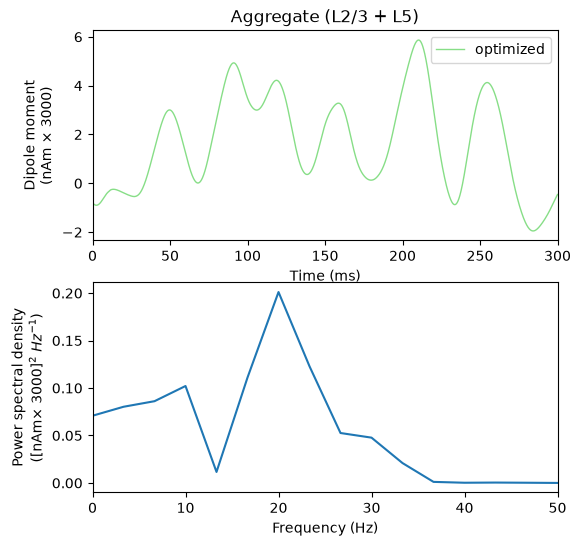

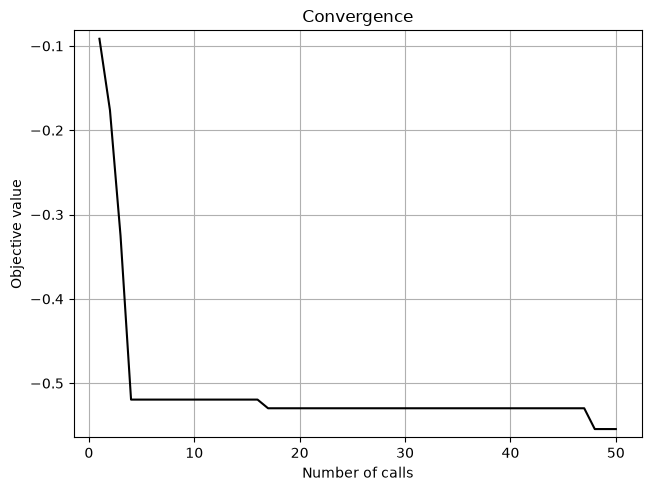

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6))

# plot dipole
opt_dpl.plot(ax=axes[0], layer='agg', show=False, color='tab:green')
axes[0].legend(['optimized'])

# plot psd
plot_psd(opt_dpl, fmax=50, ax=axes[1], show=False)

# convergence
optim.plot_convergence()
plt.show()